# Exploratory Data Analysis:

In [1]:
# load the cleaned dataset
from ReusableFunc import load_clean_data


PrData = load_clean_data(r"C:\Users\Hi\Desktop\Risk-Analysis\data\processed\PrData.csv")
print("Data loaded successfully!")

Data loaded successfully!


# Analyzing Univariate variables:


In [6]:
variables = [
    "Age",
    "Length_of_Stay",
    "Treatment_Cost",
    "Medication_Count",
    "Previous_Admissions",
    "Satisfaction_Score"
]

PrData[variables].describe().T
# saving the summary statistics to figures folder
summary_stats = PrData[variables].describe().T
summary_stats.to_csv(r"C:\Users\Hi\Desktop\Risk-Analysis\figures\summary_statistics.csv")   


# Visualizing outliers

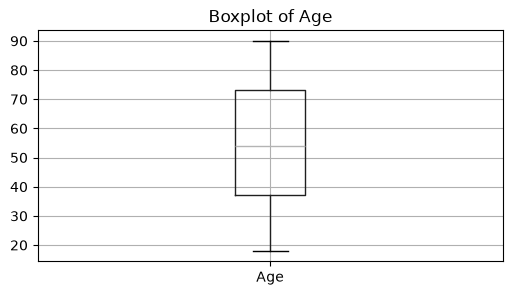

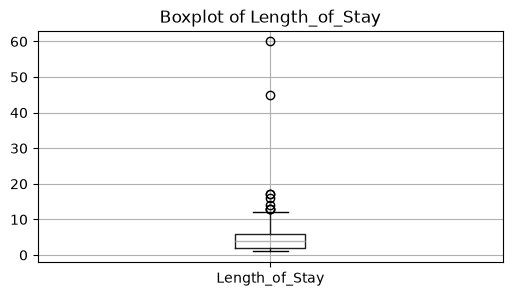

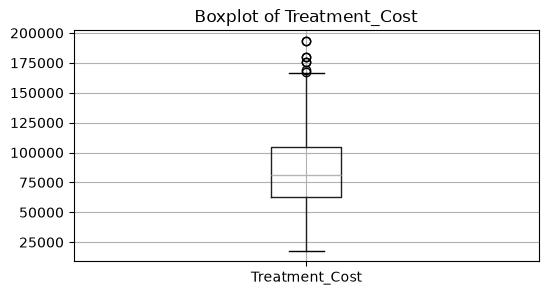

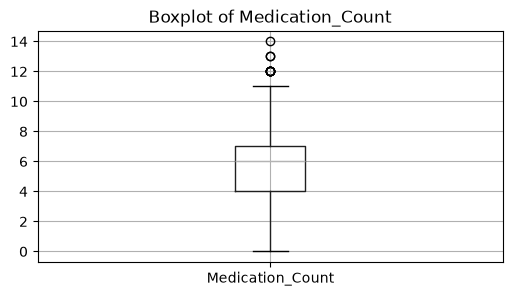

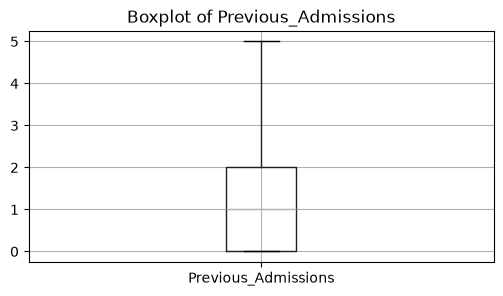

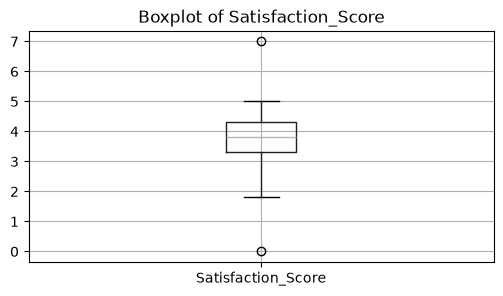

In [10]:
import matplotlib.pyplot as plt

for column in variables:
    plt.figure(figsize=(6, 3))
    PrData.boxplot(column=column)
    plt.title(f"Boxplot of {column}")
    plt.show()

# save the boxplots to the reports folder
for column in variables:
    plt.figure(figsize=(6, 3))
    PrData.boxplot(column=column)
    plt.title(f"Boxplot of {column}")
    plt.savefig(f"C:\\Users\\Hi\\Desktop\\Risk-Analysis\\figures\\boxplot_{column}.png")
    plt.close()

    

# histograms visuals:

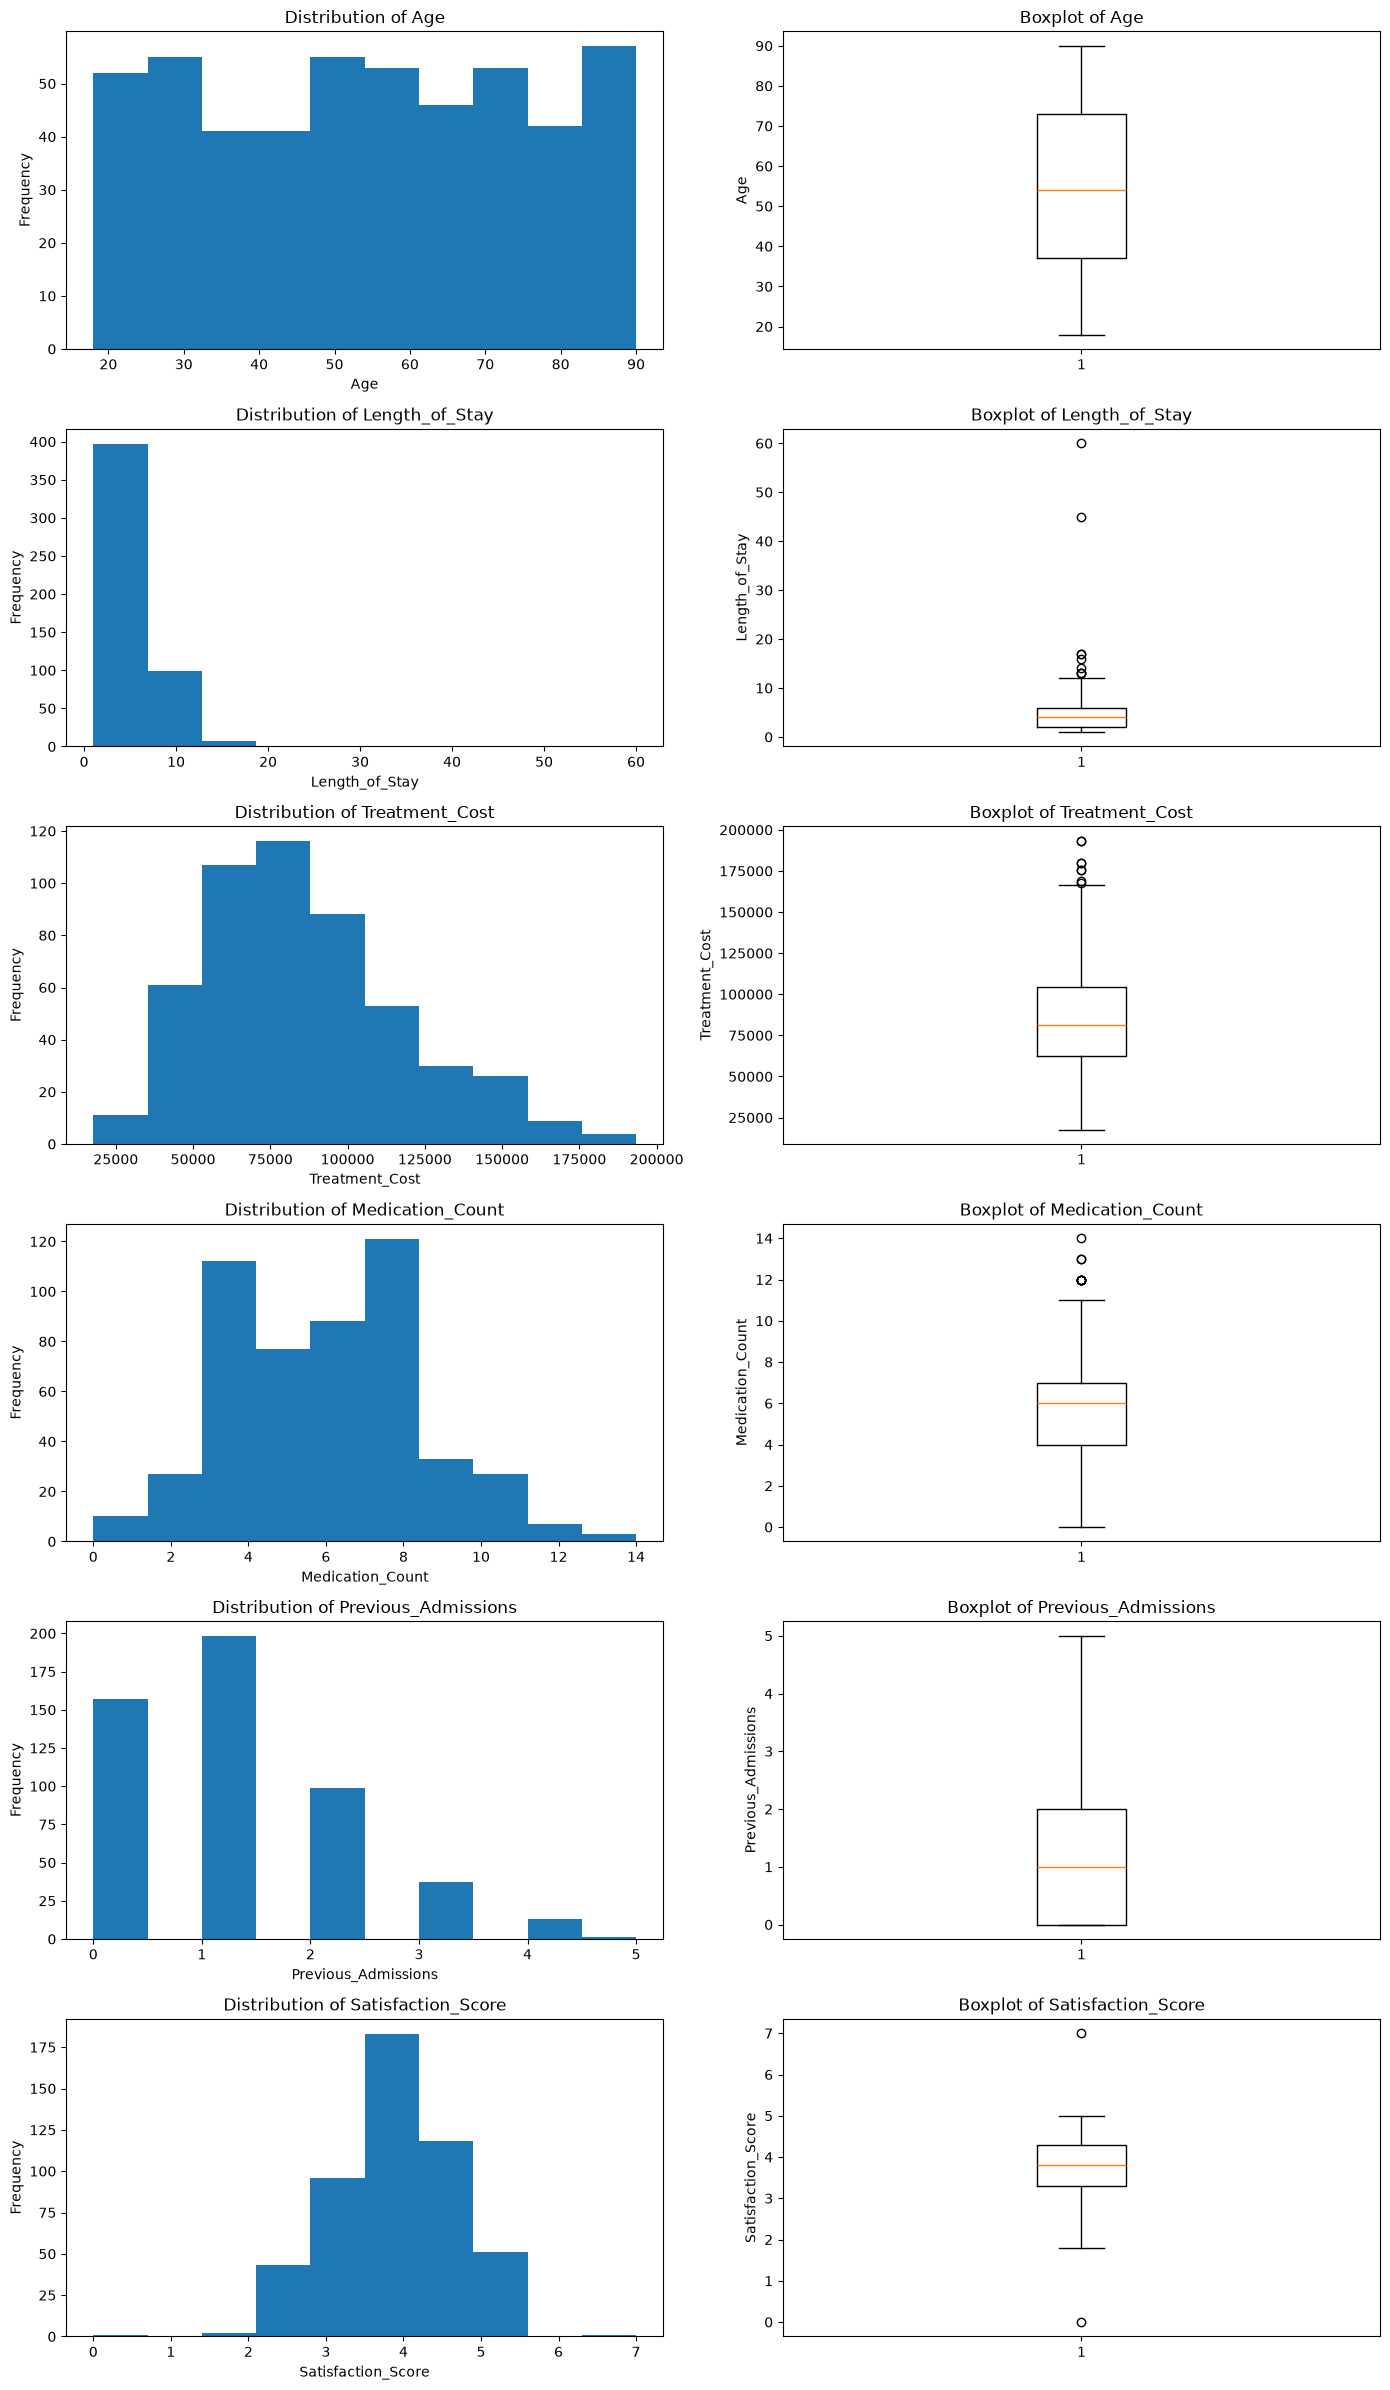

In [15]:
import matplotlib.pyplot as plt

variables = [
    "Age",
    "Length_of_Stay",
    "Treatment_Cost",
    "Medication_Count",
    "Previous_Admissions",
    "Satisfaction_Score"
]

fig, axes = plt.subplots(6, 2, figsize=(14, 24))

for i, column in enumerate(variables):

    # Histogram
    axes[i, 0].hist(PrData[column].dropna(), bins=10)
    axes[i, 0].set_title(f"Distribution of {column}")
    axes[i, 0].set_xlabel(column)
    axes[i, 0].set_ylabel("Frequency")

    # Boxplot
    axes[i, 1].boxplot(PrData[column].dropna())
    axes[i, 1].set_title(f"Boxplot of {column}")
    axes[i, 1].set_ylabel(column)

plt.tight_layout()
#plt.show()

# save the combined plots to the figures folder
plt.savefig("C:\\Users\\Hi\\Desktop\\Risk-Analysis\\figures\\combined_histogram_and_boxplots.png")
plt.show()

# Analyzing Bivariate Variables:

# Age Group vs Readmission

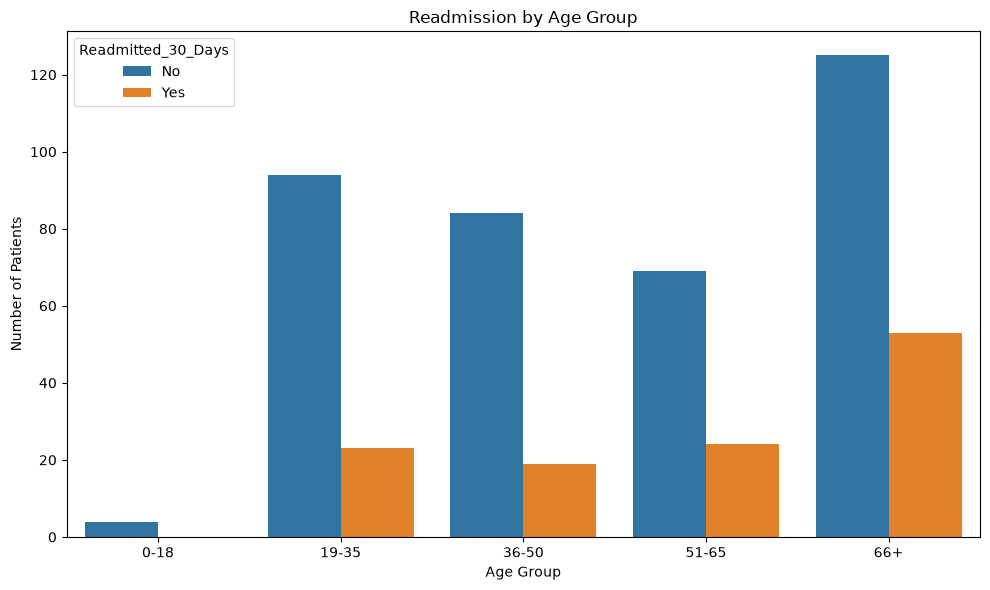

In [16]:

import pandas as pd


PrData["Age_Group"] = pd.cut(
    PrData["Age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["0-18", "19-35", "36-50", "51-65", "66+"]
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=PrData,
    x="Age_Group",
    hue="Readmitted_30_Days"
)

plt.title("Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.savefig(
    "../figures/readmission_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Gender vs Readmission-Count Plot

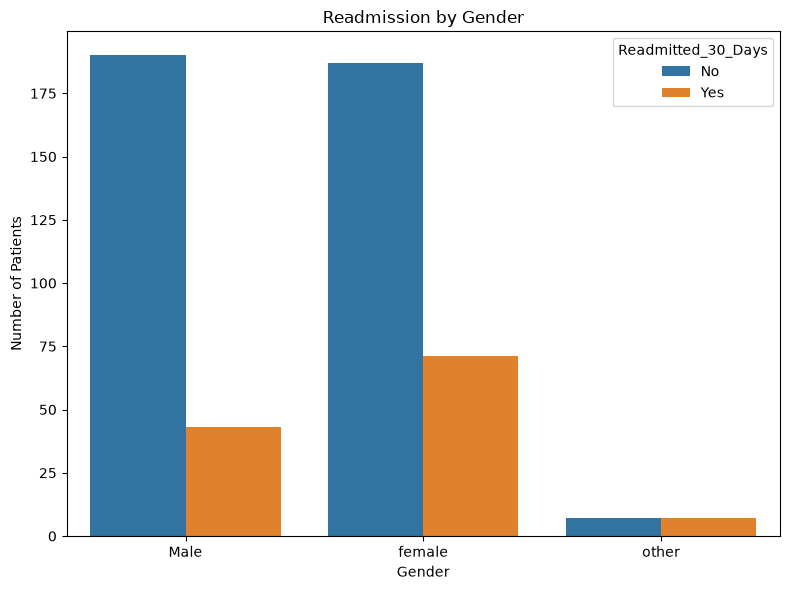

In [17]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=PrData,
    x="Gender",
    hue="Readmitted_30_Days"
)

plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.savefig(
    "../figures/readmission_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Diabetes vs Readmission- Count Plot



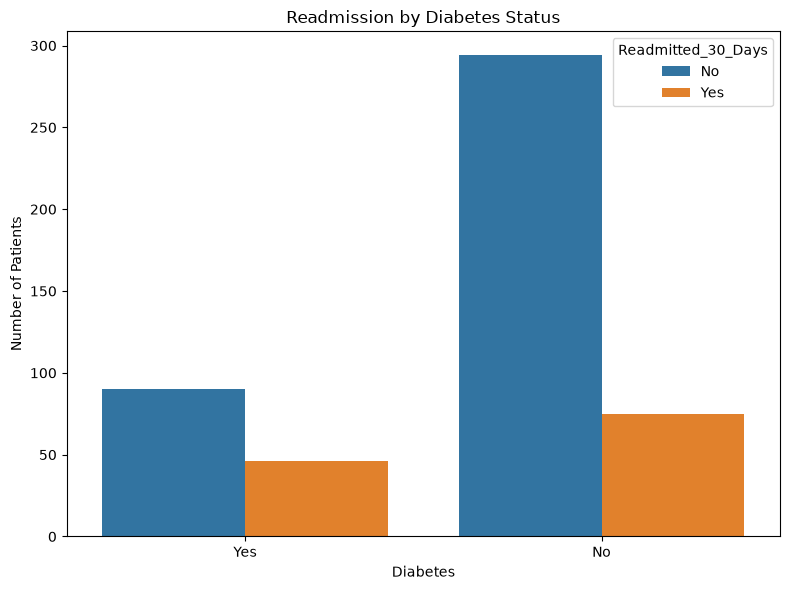

In [18]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=PrData,
    x="Diabetes",
    hue="Readmitted_30_Days"
)

plt.title("Readmission by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.savefig(
    "../figures/readmission_by_diabetes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Age vs length of stay - Scatter Plot

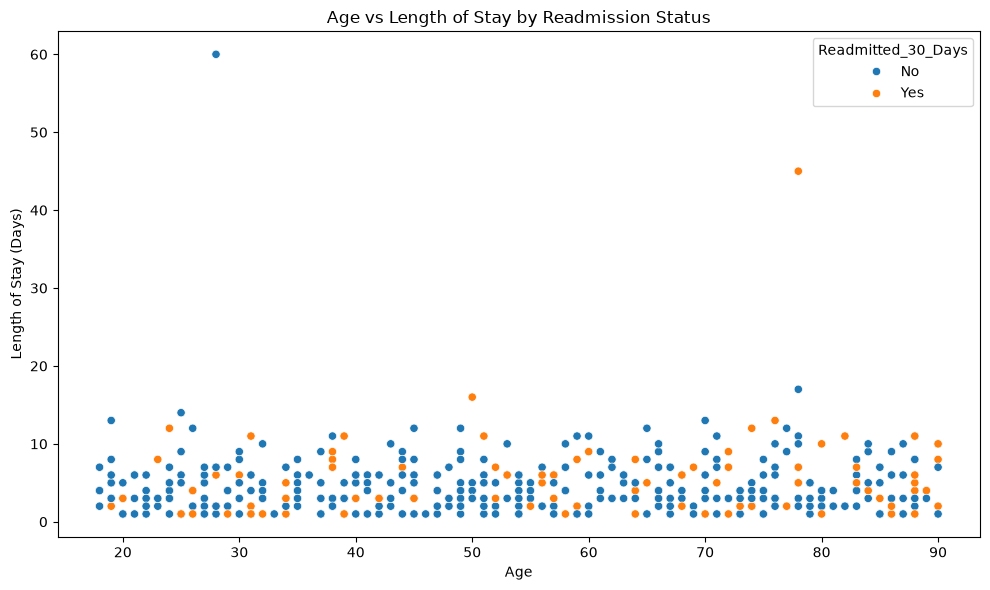

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=PrData,
    x="Age",
    y="Length_of_Stay",
    hue="Readmitted_30_Days"
)

plt.title("Age vs Length of Stay by Readmission Status")
plt.xlabel("Age")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()

plt.savefig(
    "../figures/age_vs_length_of_stay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Correlation HeatMap

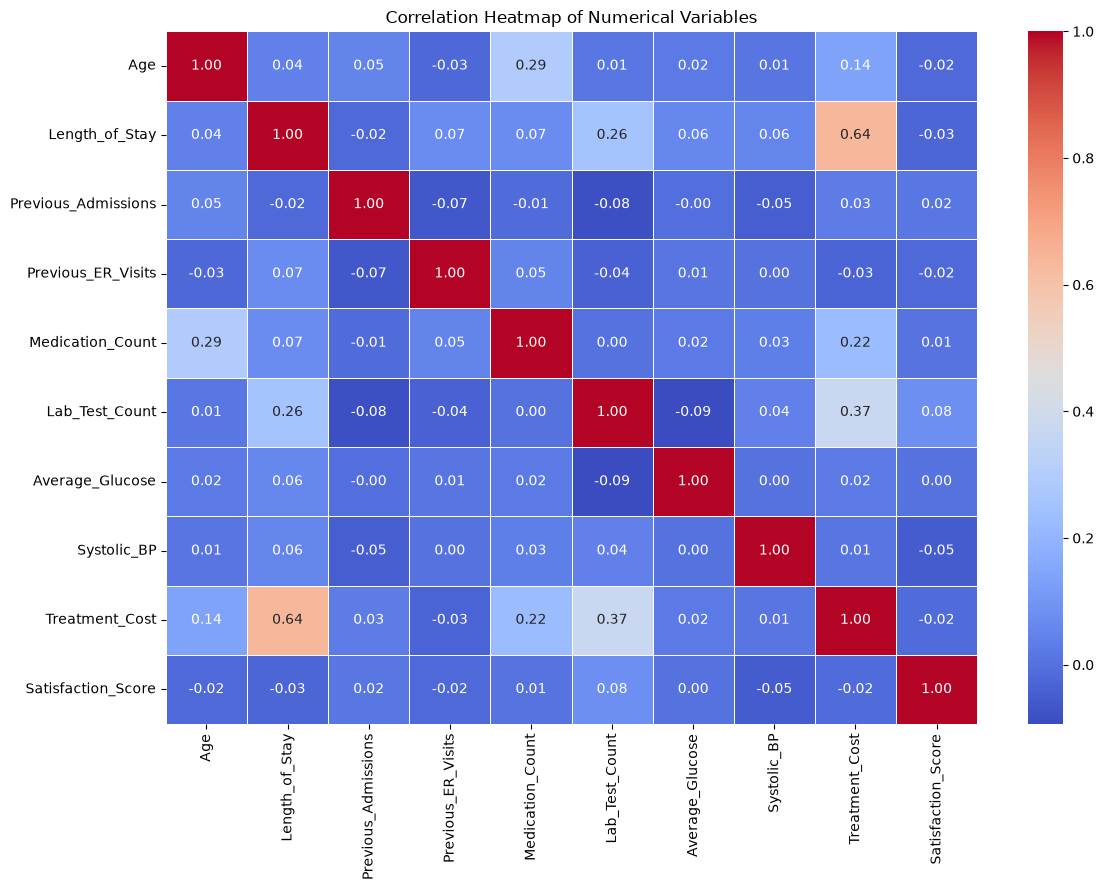

In [20]:
numeric_variables = [
    "Age",
    "Length_of_Stay",
    "Previous_Admissions",
    "Previous_ER_Visits",
    "Medication_Count",
    "Lab_Test_Count",
    "Average_Glucose",
    "Systolic_BP",
    "Treatment_Cost",
    "Satisfaction_Score"
]

correlation = PrData[numeric_variables].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()

plt.savefig(
    "../figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Readmission Pie Chart

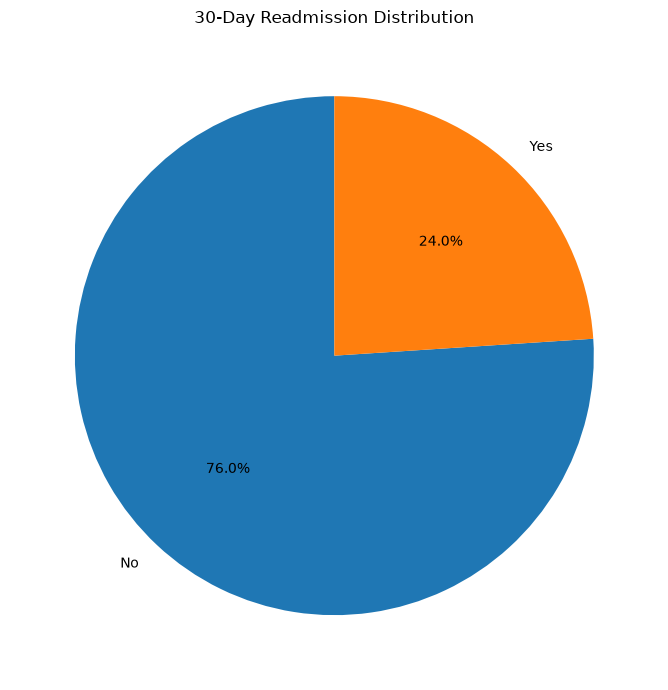

In [21]:
readmission_counts = PrData["Readmitted_30_Days"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    readmission_counts,
    labels=readmission_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("30-Day Readmission Distribution")

plt.tight_layout()

plt.savefig(
    "../figures/readmission_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()